In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

In [72]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("submission.csv")
print(train.shape)
print(test.shape)
print(sample_submission.shape)
train.head()

(1200000, 21)
(800000, 20)
(800000, 2)


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [73]:
test.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House
1,1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment
2,1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo
3,1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House
4,1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House


In [74]:
train["dataset"] = "train"
test["dataset"] = "test"
test["Premium Amount"] = np.nan
combined = pd.concat([train, test], axis=0, ignore_index=True)
print("Combined shape:", combined.shape)
combined.head()

Combined shape: (2000000, 22)


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,dataset
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,train
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,train
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,train
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,train
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,train


In [75]:
combined.isnull().sum().sort_values(ascending=False)

Premium Amount          800000
Previous Claims         606831
Occupation              597200
Credit Score            229333
Number of Dependents    182802
Customer Feedback       130100
Health Score            123525
Annual Income            74809
Age                      31194
Marital Status           30865
Vehicle Age                  9
Insurance Duration           3
Gender                       0
id                           0
Policy Type                  0
Location                     0
Education Level              0
Policy Start Date            0
Smoking Status               0
Exercise Frequency           0
Property Type                0
dataset                      0
dtype: int64

In [76]:
numeric_cols = combined.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = combined.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_cols.remove("Premium Amount")
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['id', 'Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration']
Categorical columns: ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type', 'dataset']


In [77]:
train_clean = combined[combined["dataset"] == "train"].copy()
train_clean["Premium Amount"].describe()

count    1.200000e+06
mean     1.102545e+03
std      8.649989e+02
min      2.000000e+01
25%      5.140000e+02
50%      8.720000e+02
75%      1.509000e+03
max      4.999000e+03
Name: Premium Amount, dtype: float64

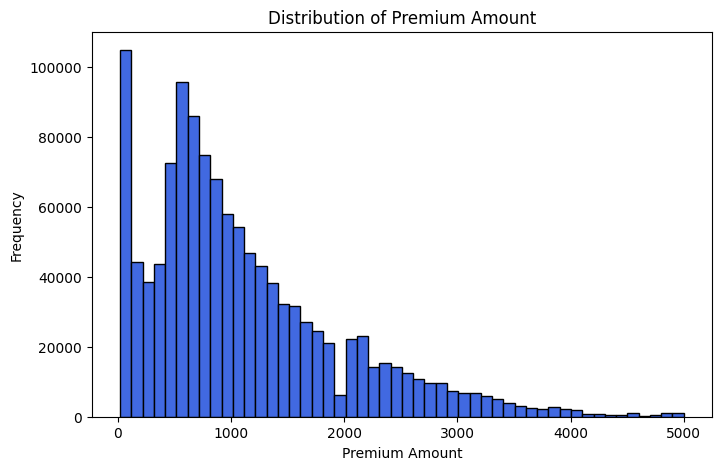

In [78]:
plt.figure(figsize=(8,5))
plt.hist(train_clean["Premium Amount"], bins=50, color="royalblue", edgecolor="black")
plt.title("Distribution of Premium Amount")
plt.xlabel("Premium Amount")
plt.ylabel("Frequency")
plt.show()

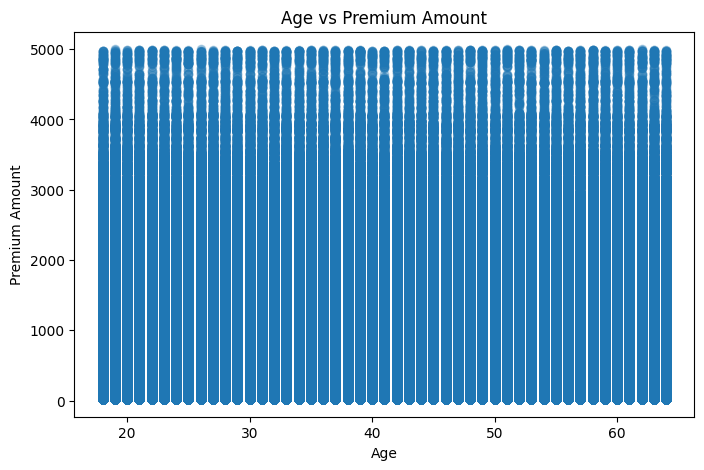

In [79]:
plt.figure(figsize=(8, 5))
plt.scatter(train_clean["Age"], train_clean["Premium Amount"],alpha=0.3)
plt.title("Age vs Premium Amount")
plt.xlabel("Age")
plt.ylabel("Premium Amount")
plt.show()

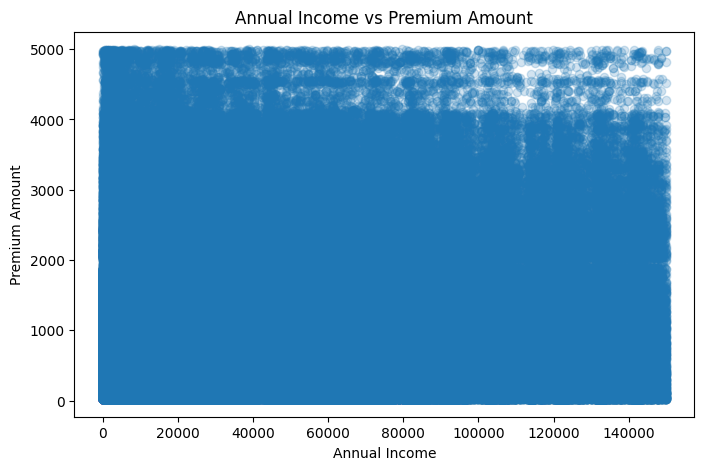

In [80]:
plt.figure(figsize=(8, 5))
plt.scatter(train_clean["Annual Income"], train_clean["Premium Amount"], alpha=0.2)
plt.title("Annual Income vs Premium Amount")
plt.xlabel("Annual Income")
plt.ylabel("Premium Amount")
plt.show()

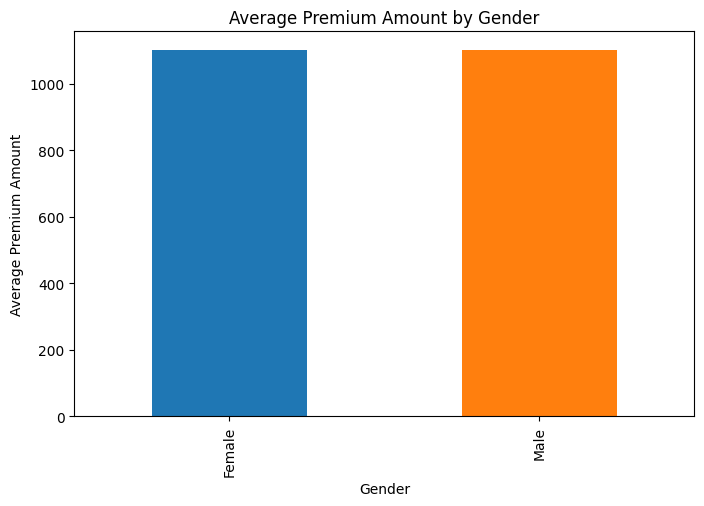

In [81]:
gender_means = train_clean.groupby("Gender")["Premium Amount"].mean()
plt.figure(figsize=(8, 5))
gender_means.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Average Premium Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Premium Amount")
plt.show()

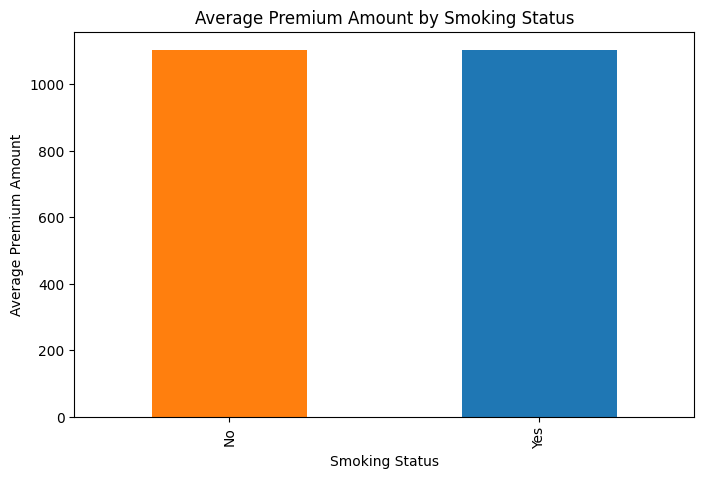

In [82]:
smoking_means = train_clean.groupby("Smoking Status")["Premium Amount"].mean()
plt.figure(figsize=(8, 5))
smoking_means.plot(kind="bar", color=["#ff7f0e", "#1f77b4"])
plt.title("Average Premium Amount by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Premium Amount")
plt.show()

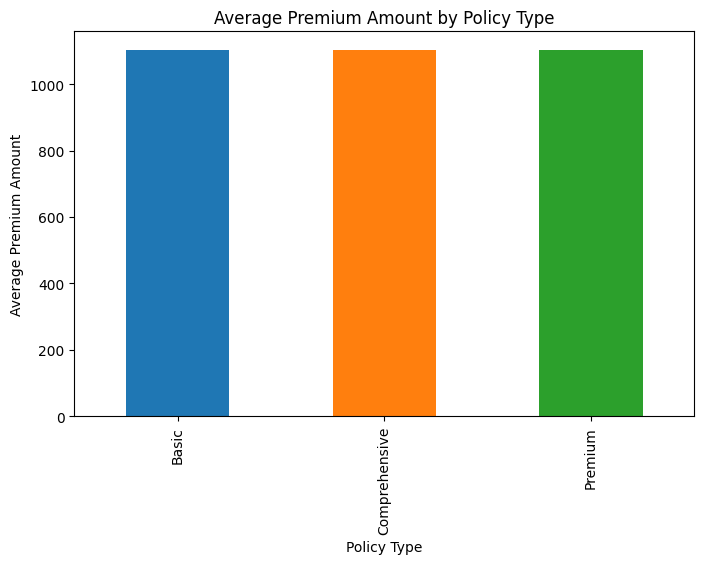

In [83]:
policy_means = train_clean.groupby("Policy Type")["Premium Amount"].mean()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
plt.figure(figsize=(8, 5))
policy_means.plot(kind="bar", color=colors[:len(policy_means)])
plt.title("Average Premium Amount by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Average Premium Amount")
plt.show()

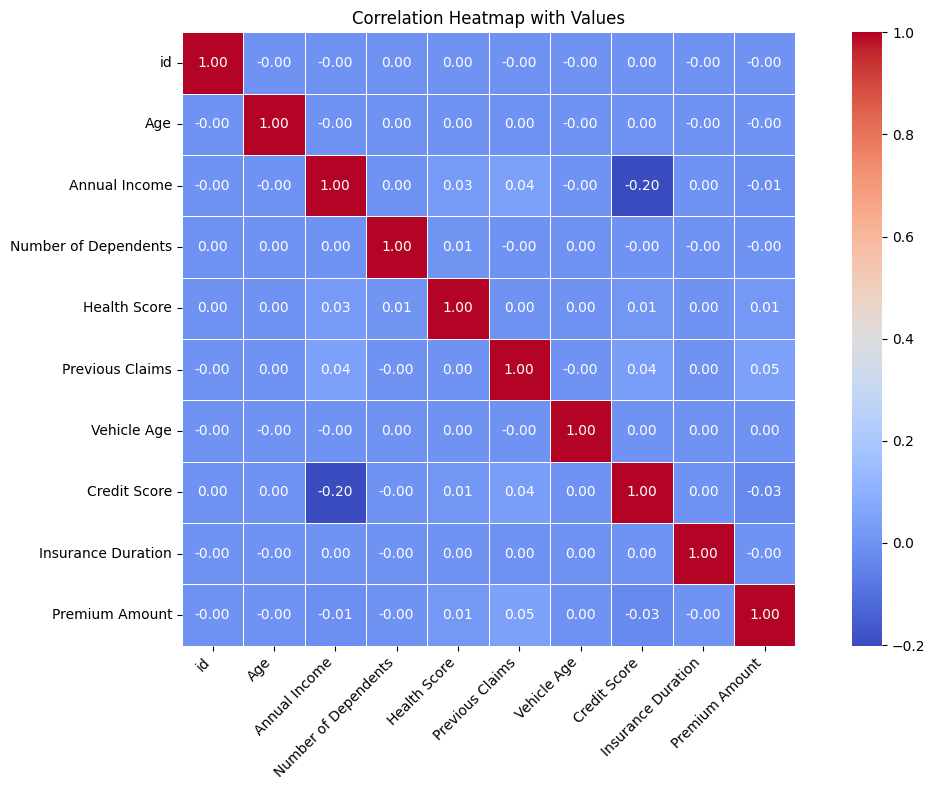

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_data = train_clean.select_dtypes(include=["int64", "float64"])
corr = numeric_data.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,          
    fmt=".2f",           
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)
plt.title("Correlation Heatmap with Values")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
train_final = combined[combined["dataset"] == "train"].copy()
test_final = combined[combined["dataset"] == "test"].copy()
train_final = train_final.drop(columns=["dataset"])
test_final = test_final.drop(columns=["dataset", "Premium Amount"])

In [86]:
X = train_final.drop(columns=["Premium Amount"])
y = train_final["Premium Amount"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1200000, 20)
y shape: (1200000,)


In [87]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training set: (960000, 20)
Validation set: (240000, 20)
Training target: (960000,)
Validation target: (240000,)


In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import numpy as np

In [33]:
train_m2 = train.copy()
test_m2 = test.copy()

In [97]:
def add_policy_date_features(df):
    df = df.copy()

    if "Policy Start Date" in df.columns:
        df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"])

        df["Policy Year"] = df["Policy Start Date"].dt.year
        df["Policy Month"] = df["Policy Start Date"].dt.month
        df["Policy Day"] = df["Policy Start Date"].dt.day
        df["Policy DayOfWeek"] = df["Policy Start Date"].dt.dayofweek

        df["Policy Month Sin"] = np.sin(2 * np.pi * df["Policy Month"] / 12)
        df["Policy Month Cos"] = np.cos(2 * np.pi * df["Policy Month"] / 12)

        df["Policy DayOfWeek Sin"] = np.sin(2 * np.pi * df["Policy DayOfWeek"] / 7)
        df["Policy DayOfWeek Cos"] = np.cos(2 * np.pi * df["Policy DayOfWeek"] / 7)

        df = df.drop(columns=["Policy Start Date"])

    return df

In [98]:
train_m2 = train.copy()
test_m2 = test.copy()

train_m2 = add_policy_date_features(train_m2)
test_m2 = add_policy_date_features(test_m2)

In [99]:
train_m2["Gender"] = train_m2["Gender"].map({"Male": 1, "Female": 0})
test_m2["Gender"] = test_m2["Gender"].map({"Male": 1, "Female": 0})
train_m2["Smoking Status"] = train_m2["Smoking Status"].map({"Yes": 1, "No": 0})
test_m2["Smoking Status"] = test_m2["Smoking Status"].map({"Yes": 1, "No": 0})

In [100]:
education_order = ["High School", "Bachelor's", "Master's", "PhD"]
feedback_order = ["Poor", "Average", "Good"]
ordinal_features = ["Education Level", "Customer Feedback"]
ordinal_encoder = OrdinalEncoder(
    categories=[education_order, feedback_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

In [101]:
X = train_m2.drop(columns=["Premium Amount"])
y = train_m2["Premium Amount"]
X_test = test_m2.copy()
test_ids = X_test["id"]
X = X.drop(columns=["id"])
X_test = X_test.drop(columns=["id"])

In [102]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
ordinal_features = ["Education Level", "Customer Feedback"]
nominal_features = [
    col for col in X.select_dtypes(include=["object", "string"]).columns.tolist()
    if col not in ordinal_features
]
print("Numeric features:", numeric_features)
print("Ordinal features:", ordinal_features)
print("Nominal features:", nominal_features)

Numeric features: ['Age', 'Gender', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Smoking Status', 'Policy Month Sin', 'Policy Month Cos', 'Policy DayOfWeek Sin', 'Policy DayOfWeek Cos']
Ordinal features: ['Education Level', 'Customer Feedback']
Nominal features: ['Marital Status', 'Occupation', 'Location', 'Policy Type', 'Exercise Frequency', 'Property Type', 'dataset']


In [103]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", ordinal_encoder)
])
nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("ord", ordinal_pipeline, ordinal_features),
        ("nom", nominal_pipeline, nominal_features)
    ]
)

In [104]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [105]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    )
}

In [106]:
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, preds))
    results[name] = rmse
    print(name, "RMSE:", rmse)

Linear Regression RMSE: 863.3168524072934
Decision Tree RMSE: 1240.5124581162684
Random Forest RMSE: 860.6353614108184
Hist Gradient Boosting RMSE: 846.2009036329462


In [107]:
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "RMSE": list(results.values())
}).sort_values(by="RMSE")
results_df

,Model,RMSE
3,Hist Gradient Boosting,846.200904
2,Random Forest,860.635361
0,Linear Regression,863.316852
1,Decision Tree,1240.512458


In [45]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

In [46]:
param_grid = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_iter": [100, 200],
    "model__max_leaf_nodes": [31, 63],
    "model__l2_regularization": [0.0, 0.1]
}

In [47]:
grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__l2_regularization': [0.0, 0.1], 'model__learning_rate': [0.05, 0.1], 'model__max_iter': [100, 200], 'model__max_leaf_nodes': [31, 63]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [108]:
print("Best parameters:")
print(grid_search.best_params_)
print("Best CV RMSE:")
print(-grid_search.best_score_)

Best parameters:
{'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_iter': 100, 'model__max_leaf_nodes': 63}
Best CV RMSE:
846.14975565343


In [110]:
best_model = grid_search.best_estimator_
valid_preds = best_model.predict(X_valid)
final_rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
print("Final Validation RMSE:", final_rmse)

Final Validation RMSE: 845.9827666201094


In [ ]:
comparison = pd.DataFrame({
    "Actual Premium": y_valid.values,
    "Predicted Premium": valid_preds
})
comparison.head(10)

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_valid, valid_preds, alpha=0.3, s=10)
plt.title("Actual vs Predicted Premium Amount")
plt.xlabel("Actual Premium Amount")
plt.ylabel("Predicted Premium Amount")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
errors = y_valid - valid_preds
plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
test_predictions = best_model.predict(X_test)
test_predictions[:10]

In [ ]:
submission = pd.DataFrame({
    "id": test_ids,
    "Premium Amount": test_predictions
})
submission.head()

In [55]:
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!
